# Function calling
	1. Make a request to the model with tools it could call
	2. Receive a tool call from the model
	3. Execute code on the application side with input from the tool call
	4. Make a second request to the model with the tool output
	5. Receive a final response from the model (or more tool calls)


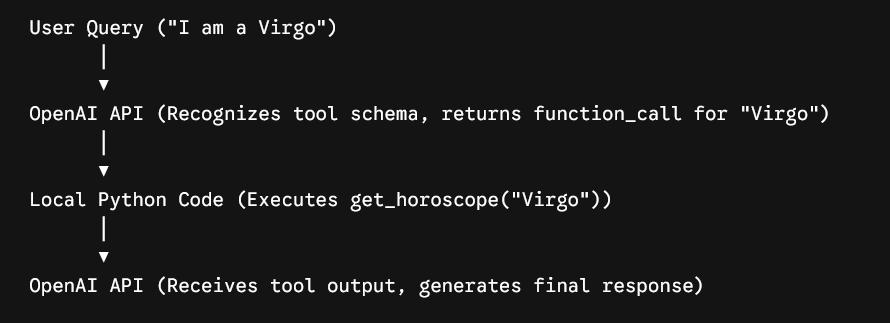

In [ ]:
from dotenv import load_dotenv
from openai import OpenAI
import json
load_dotenv()
client = OpenAI()

tools = [
    {
        "type": "function",
        "name": "get_horoscope",
        "description":"Get today's horoscope for an astrological sign.",
        "parameters": {
            "type": "object",
            "properties": {
                "sign": {
                    "type": "string",
                    "description": "An astrological sign like Taurus or Aquarius",
                },
            },
            "required": ["sign"],
        },
    },
    {
        "type": "function",
        "name": "wish_name",
        "description":"Wishing to person with name",
        "parameters":{
            "type":"object",
            "properties":{
                "name":{
                    "type":"string",
                    "description": "Enter person name like Sanjay or Steve",
                },
            },
            "required":["name"],
        },
    },
]

def get_horoscope(sign):
    return f"{sign}: Next Tuesday you will befriend a baby otter."

def wish_name(name):
    return f"Hi {name} , greetings!"

# Create a running input list we will add to over time
input_list = [{"role": "user", "content": "My name is Sanjay. What is my horoscope? I am a Virgo."}]

# 2. Prompt the model with tools defined
response = client.responses.create(
    model="gpt-5.6",
    tools=tools,
    input=input_list,
)

# Save function call outputs for subsequent requests
input_list += response.output

for item in response.output:
    if item.type == "function_call":
        if item.name == "get_horoscope":
            # 3. Execute the function logic for get_horoscope
            sign = json.loads(item.arguments)["sign"]
            horoscope = get_horoscope(sign)
                        # 4. Provide function call results to the model
            input_list.append(
                {
                    "type": "function_call_output",
                    "call_id": item.call_id,
                    "output": horoscope,
                }
            )
        if item.name == "wish_name":
            name = json.loads(item.arguments)["name"]
            greet = wish_name(name)
            input_list.append(
                {
                    "type": "function_call_output",
                    "call_id": item.call_id,
                    "output": greet,
                }
            )


print("Final input:")
print(input_list)

response = client.responses.create(
    model="gpt-5.6",
    instructions="Greet a person then Respond with a horoscope generated by a tool.",
    tools=tools,
    input=input_list,
)

# 5. The model should be able to give a response!
print("Final output:")
print(response.model_dump_json(indent=2))
print("\n" + response.output_text)

# Outputs
# Hi Sanjay, greetings!  
# **Virgo horoscope:** Next Tuesday, you will befriend a baby otter. 🦦


Final input:
[{'role': 'user', 'content': 'My name is Sanjay. What is my horoscope? I am a Virgo.'}, ResponseReasoningItem(id='rs_08e7e2f9c993eccf006a7376cd9d60819798bd997fac643cf0', summary=[], type='reasoning', content=[], encrypted_content='gAAAAABqc3bODsLWaRNxaiKHLPbx-6TSgwQSVS5YhNSYX3OaMSib-qTbps1Wi3ACSOqDDoBoeWJbO86xAufkyPsC1Jznb659yPPadWBzKKWvG997c7lRRXIhSAHZMUdHfuzuTuAY3cDr171Ai2DhbpnzQrKgzzbQlTCAnPOp9YlM_MWa_aGYG3S-VkcZj9Oyep0gxP0zAI-j5qYFk5KxRGdC-lj476LgGNAUVD825DOCnxJIhPCw37t8f87r1nI1z4wj8E5Hv5AoImfOKqUEPAU2yhAeRN4Tzu2Xu2zXiwIKYpjhTBaTDFNltW9LwjF3kj3OmPfaaizF0afQFWwBBVoYmEbfREA30Tf457UK9uhbJc0Y58qjER2Io_BBdXqeXZ03eW6q66TsbR9LANdDOBZJ69HiCY2x6BmE-dcx0J7nolEzaUrbBDANH3cJdXmvSE2K9il3fStVEGJAOWGJrE6wlBMZH5CB96KHPvvlNeFFIskFhaA8TlImjcFyNXMf6ZjeL9ygkC2mDPPCa8cWbCx3sSKSrlHNavPC7Fk-CR2f7Rd2iTb7FCe1tYZwuvluBVaNM9Q_4sR0GjUHd3M4TQShy3lIpGXZodmRSiS11Fbbzm49Wi9sgdcKmOmv_-WwwNjbxhVmMW7pFPiZ40-uAod35KZ5wzwUsyBn0P9JO38ZbgOgtDmTtKgZTvIRU_RqHXSRzGoVZckK3sXriwqvB68faY4Y23C_VoSA_cMVJftwSKhZqwNP

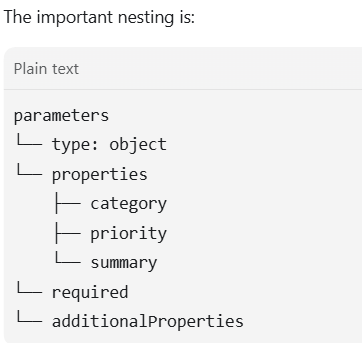